EDA

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [6]:
df = pd.read_csv("CreditCardTransaction.csv")

In [7]:
df.head()

,Year,Month,Department,Division,Merchant,TranxDescription,TranxDate,TrnxAmount
0,2019,1,LEGISLATIVE BRANCH,General Assembly House,USPS PO 0917600901,Postal Services-Government Only,06/29/2018,9.85
1,2019,1,LEGISLATIVE BRANCH,General Assembly House,GAN*NEWSPAPER SUB1052,Direct Marketing-Continuity-Subscription Merch...,07-03-2018,15.00
2,2019,1,LEGISLATIVE BRANCH,General Assembly House,DS SERVICES STANDARD COFF,Nondurable Goods Not Elsewhere Classified,07-01-2018,170.31
3,2019,1,LEGISLATIVE BRANCH,General Assembly House,BETHANY BLUES - LEWES,Eating Places Restaurants,06/30/2018,3427.80
4,2019,1,LEGISLATIVE BRANCH,General Assembly House,XEROX CORPORATION/RBO,Office Photographic Photocopy Microfilm Equipmt,06/27/2018,113.06


In [8]:
df.shape

(788521, 8)

In [9]:
df.describe()

,Year,Month,TrnxAmount
count,788521.000000,788521.000000,788521.000000
mean,2020.750357,6.076380,428.631052
std,1.381895,3.383734,2482.957235
min,2019.000000,1.000000,-86114.200000
25%,2020.000000,3.000000,22.000000
50%,2021.000000,6.000000,70.950000
75%,2022.000000,9.000000,259.880000
max,2023.000000,12.000000,432159.840000


In [10]:
df['TrnxAmount'].sum()

np.float64(337984585.70000005)

In [11]:
df['TrnxAmount'].mean()

np.float64(428.63105193140075)

In [12]:
df['TrnxAmount'].max()

432159.84

In [14]:
df['TranxDate'] = pd.to_datetime(
    df['TranxDate'],
    errors='coerce'
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788521 entries, 0 to 788520
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Year              788521 non-null  int64         
 1   Month             788521 non-null  int64         
 2   Department        788521 non-null  object        
 3   Division          788521 non-null  object        
 4   Merchant          788521 non-null  object        
 5   TranxDescription  788521 non-null  object        
 6   TranxDate         464505 non-null  datetime64[ns]
 7   TrnxAmount        788521 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 48.1+ MB


In [15]:
dept_spend = (
    df.groupby('Department')['TrnxAmount']
      .sum()
      .sort_values(ascending=False)
)

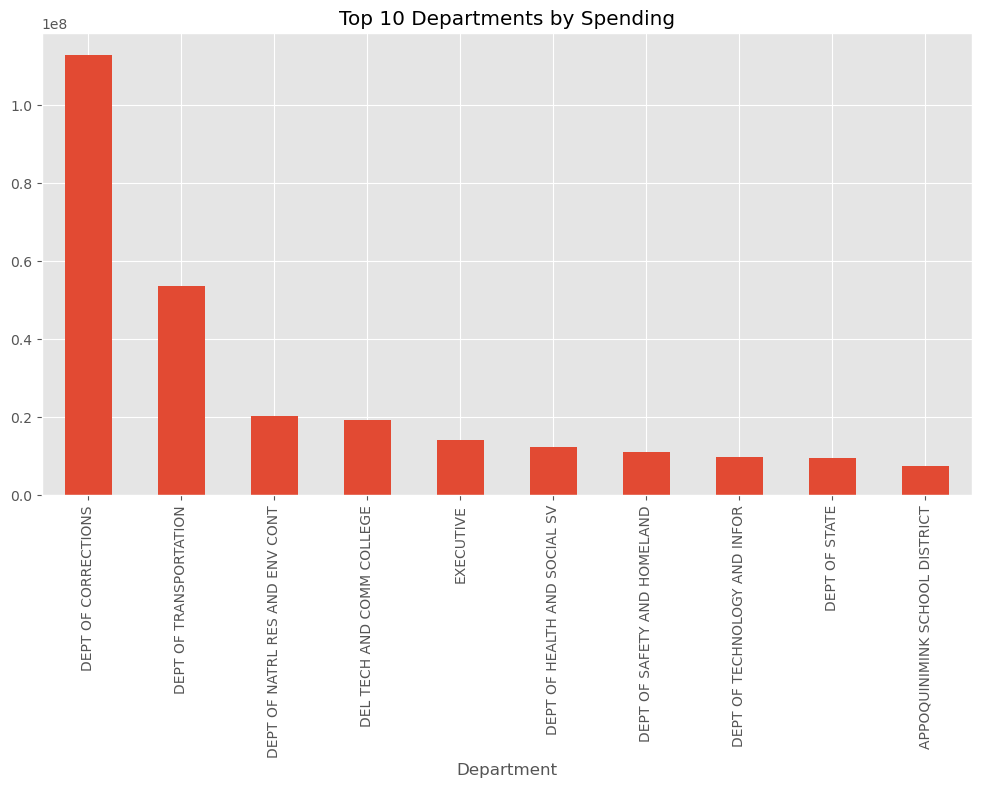

In [16]:
plt.figure(figsize=(12,6))

dept_spend.head(10).plot(kind='bar')

plt.title("Top 10 Departments by Spending")
plt.show()

In [17]:
monthly_spend = (
    df.groupby(['Year','Month'])
      ['TrnxAmount']
      .sum()
)

In [18]:
merchant_spend = (
    df.groupby('Merchant')['TrnxAmount']
      .sum()
      .sort_values(ascending=False)
)

In [19]:
merchant_spend.head(20)

Merchant
H. SCHRIER And CO. INC.     12065335.01
VERIZON*ONETIMEPAYMENT       6487997.07
VERIZONWRLSS*RTCCR VB        6160105.82
CITY OF WILM-DIV REVENUE     5941766.66
CITY OF WILMINGTON           4833667.93
CAN*CANONFINANCIAL CFS       4589065.46
GRAINGER                     4251079.57
WASTE MGMT WM EZPAY          4235806.15
MTM TECHNOLOGIES INC         4089670.96
DMI* DELL HLTHCR/REL         3935941.09
GOOD SOURCE SOLUTIONS        3544186.76
HANOVER UNIFORM CO           3485795.78
BI INC AP                    3134559.35
SCHMIDT BAKING CO.           3057785.54
STATE JANITORAL SUPPLY       3043041.62
THE CLASS PRODUCE GROUP      3002128.24
VERITIV-EAST                 2717484.54
GRIFFITH ENERGY SERVIC       2536585.75
KARETAS FOODS                2504804.19
BARR INTERNATIONAL           2497569.32
Name: TrnxAmount, dtype: float64

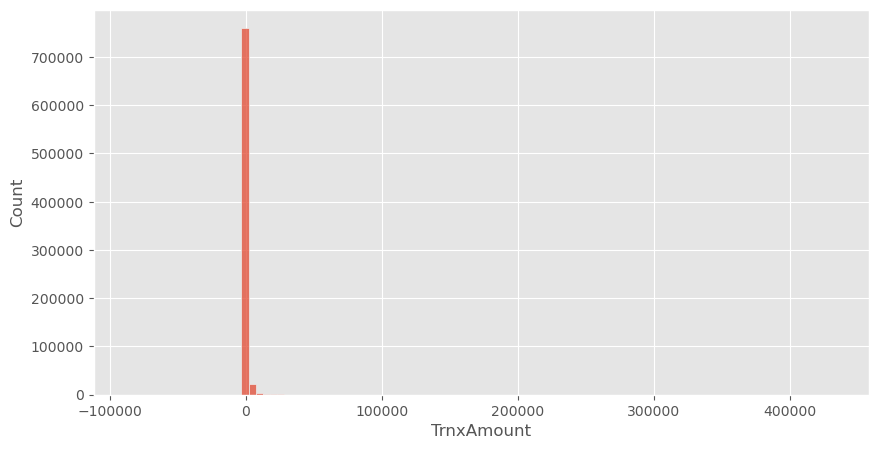

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['TrnxAmount'],
    bins=100
)

plt.show()

<Axes: xlabel='TrnxAmount'>

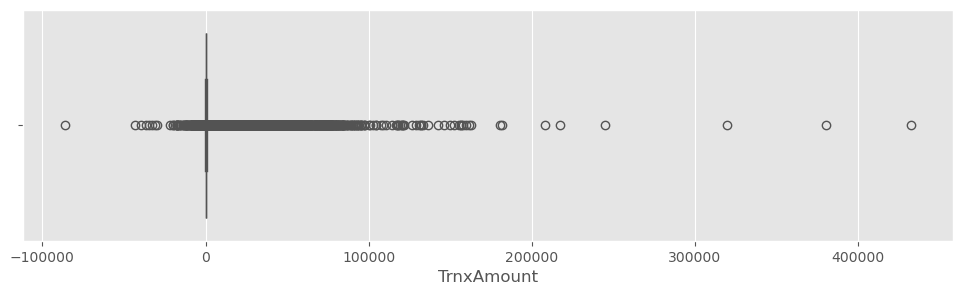

In [21]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=df['TrnxAmount']
)

In [22]:
q1 = df['TrnxAmount'].quantile(0.25)

q3 = df['TrnxAmount'].quantile(0.75)

iqr = q3 - q1

upper = q3 + 1.5 * iqr

In [23]:
df['Rule_Outlier'] = (
    df['TrnxAmount'] > upper
).astype(int)

In [24]:
df['Rule_Outlier'].value_counts()

Rule_Outlier
0    692832
1     95689
Name: count, dtype: int64

In [25]:
df['TrnxAmount'].describe()

count    788521.000000
mean        428.631052
std        2482.957235
min      -86114.200000
25%          22.000000
50%          70.950000
75%         259.880000
max      432159.840000
Name: TrnxAmount, dtype: float64

In [26]:
dept_spend.head(10)

Department
DEPT OF CORRECTIONS               1.128638e+08
DEPT OF TRANSPORTATION            5.359097e+07
DEPT OF NATRL RES AND ENV CONT    2.034449e+07
DEL TECH AND COMM COLLEGE         1.915310e+07
EXECUTIVE                         1.407209e+07
DEPT OF HEALTH AND SOCIAL SV      1.227879e+07
DEPT OF SAFETY AND HOMELAND       1.097133e+07
DEPT OF TECHNOLOGY AND INFOR      9.799424e+06
DEPT OF STATE                     9.444309e+06
APPOQUINIMINK SCHOOL DISTRICT     7.356621e+06
Name: TrnxAmount, dtype: float64

In [27]:
merchant_spend.head(10)

Merchant
H. SCHRIER And CO. INC.     12065335.01
VERIZON*ONETIMEPAYMENT       6487997.07
VERIZONWRLSS*RTCCR VB        6160105.82
CITY OF WILM-DIV REVENUE     5941766.66
CITY OF WILMINGTON           4833667.93
CAN*CANONFINANCIAL CFS       4589065.46
GRAINGER                     4251079.57
WASTE MGMT WM EZPAY          4235806.15
MTM TECHNOLOGIES INC         4089670.96
DMI* DELL HLTHCR/REL         3935941.09
Name: TrnxAmount, dtype: float64

ML PREPARATION

In [28]:
df['TranxDate'] = pd.to_datetime(df['TranxDate'])

df['Year'] = df['TranxDate'].dt.year
df['Month_Num'] = df['TranxDate'].dt.month
df['Day'] = df['TranxDate'].dt.day
df['Weekday'] = df['TranxDate'].dt.day_name()

In [29]:
df['SizeCategory'] = pd.cut(
    df['TrnxAmount'],
    bins=[-100000,0,100,1000,10000,500000],
    labels=[
        'Negative',
        'Small',
        'Medium',
        'Large',
        'Very Large'
    ]
)

In [30]:
df['SizeCategory'].value_counts()

SizeCategory
Small         432423
Medium        279178
Large          54619
Negative       18376
Very Large      3925
Name: count, dtype: int64

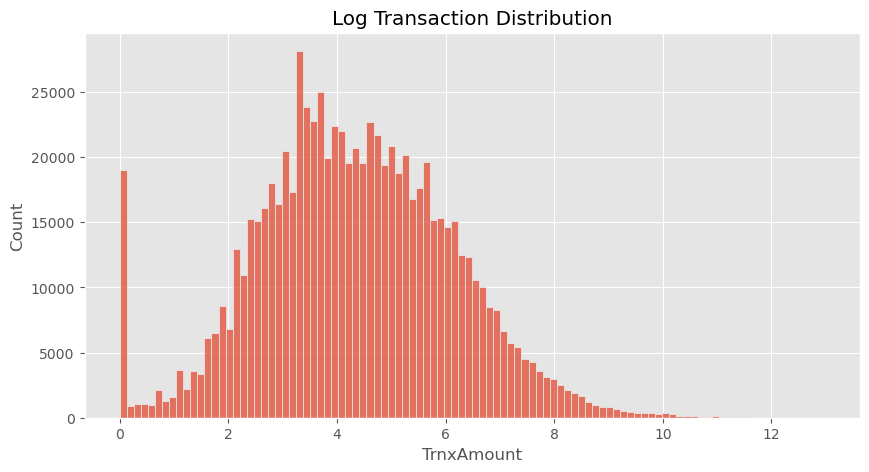

In [31]:
import numpy as np

plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df['TrnxAmount'].clip(lower=0)),
    bins=100
)

plt.title("Log Transaction Distribution")
plt.show()